# Unified Agent Comparison Notebook

This notebook provides a unified framework to compare different agents (PRF, Reranking) against BM25 baseline.
Configure parameters in Cell 1 to select which agent to run.

In [ ]:
# ============================================================================
# CELL 1: CONSTANTS AND PARAMETERS
# ============================================================================

# ===== FILE PATHS =====
DATA_FILE = "msmarco_queries_qrels.csv"

# ===== RETRIEVAL PARAMETERS =====
TOP_K = 50
NUM_QUERIES = 200
IS_NDCG_0_SUBSET = False  # Set to True to use the subset of queries with NDCG@10=0 for baseline

# ===== AGENT PARAMETERS =====
VERBOSE = False  # Set to True to print detailed agent execution logs

# ===== AGENT SELECTION WITH ORDERING =====
# Agents: [0]=PRF, [1]=Reranking, [2]=Reformulate, [3]=Intent
# 
# AGENT_SELECTION is now a list of vectors specifying the order of agent execution.
# Each vector is a one-hot encoding indicating which agent to apply at that step.
# 
# Examples:
#   [[0,0,1,0]]                  = Apply Reformulate only
#   [[1,0,0,0]]                  = Apply PRF only
#   [[0,0,0,1]]                  = Apply Intent only
#   [[0,1,0],[0,0,1]]            = Apply Reranking first, then Reformulate
#   [[0,0,0,1],[0,1,0]]          = Apply Intent first, then Reranking
#   [[1,0,0],[0,1,0],[0,0,1]]    = Apply PRF, then Reranking, then Reformulate
# 
# To use baseline only, use empty list: []
#
AGENT_SELECTION = [[0,0,1,0], [0,1,0,0]]  # Change this to select agents and their order

# Flatten AGENT_SELECTION to determine which agents to initialize
agents_to_initialize = [0, 0, 0, 0]
for agent_vector in AGENT_SELECTION:
    for idx, is_selected in enumerate(agent_vector):
        if is_selected:
            agents_to_initialize[idx] = 1

AGENT_NAMES = ["PRF", "Reranking", "Reformulate", "Intent"]
selected_agents = [AGENT_NAMES[i] for i in range(len(AGENT_NAMES)) if agents_to_initialize[i]]
agent_combination_name = " → ".join(selected_agents) if selected_agents else "Baseline"

# Build agent execution order from AGENT_SELECTION
agent_execution_order = []
for agent_vector in AGENT_SELECTION:
    for agent_pos, is_selected in enumerate(agent_vector):
        if is_selected:
            agent_execution_order.append(AGENT_NAMES[agent_pos])
            break
agent_order_str = " → ".join(agent_execution_order) if agent_execution_order else "None"

print(f"✓ Configuration loaded")
print(f"  Data file: {DATA_FILE}")
print(f"  Top-K: {TOP_K}")
print(f"  Selected Agent(s): {agent_combination_name}")
print(f"  Agent Execution Order: {agent_order_str}")
print(f"  Number of queries: {NUM_QUERIES}")# ============================================================================

# CELL 2: SETUP - All imports, initialization, and utility functions
# ============================================================================

import sys
from pathlib import Path
import pandas as pd
import numpy as np
from collections import defaultdict
from typing import Dict, List, Tuple
import logging
import matplotlib.pyplot as plt
from contextlib import redirect_stdout, redirect_stderr
import io

from src.agents.reformlate2 import ReformulationAgent

# Add src to path

src_path = Path.cwd().parent / "src"
sys.path.insert(0, str(src_path))

from sentence_transformers import SentenceTransformer
from src.utils.retriever import Retriever, create_retriever_callable
from src.agents.prf import PRFAgent
from src.agents.rerank import RerankingAgent

from src.simulation import Simulation

# Configure logging
logging.basicConfig(level=logging.WARNING)
logger = logging.getLogger(__name__)

# Suppress urllib3 InsecureRequestWarning
import warnings
from urllib3.exceptions import InsecureRequestWarning
warnings.simplefilter('ignore', InsecureRequestWarning)

print("✓ All libraries imported successfully")

# Load the CSV file with qrels
data_path = Path.cwd() / DATA_FILE

if not data_path.exists():
    print(f"⚠️  Warning: CSV not found at {data_path}")
    print(f"Please ensure {DATA_FILE} exists in data directory")
else:
    df_qrels = pd.read_csv(data_path)
    print(f"✓ Loaded qrels CSV with {len(df_qrels)} entries")
    print(f"✓ Unique queries: {df_qrels['query_id'].nunique()}")
    print(f"\nSample entries:")
    print(df_qrels.head())

# Get unique queries
sample_queries = sorted(df_qrels['query_id'].unique())[:NUM_QUERIES]
print(f"\n✓ Will evaluate {len(sample_queries)} queries: {sample_queries}")

# Initialize sentence transformer (for embedding)
print("\nLoading sentence transformer model...")
encoder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
print("✓ Encoder loaded")

# Initialize retriever
print("Setting up retriever...")
retriever_instance = Retriever()
retriever_func = create_retriever_callable(retriever_instance)
print("✓ Retriever initialized")

# Initialize selected agents
print(f"Setting up agents...")
agents = {}
if agents_to_initialize[1]:  # Reranking
    # Suppress model loading output unless VERBOSE is True
    if not VERBOSE:
        with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
            agents['Reranking'] = RerankingAgent(embed_model=encoder)
    else:
        agents['Reranking'] = RerankingAgent(embed_model=encoder)
    print(f"  ✓ Reranking agent initialized")
if agents_to_initialize[2]:  # Reformulate
    agents['Reformulate'] = ReformulationAgent(embed_model=encoder)
    print(f"  ✓ Reformulate agent initialized")


# Helper function to normalize doc_ids
def normalize_doc_id(doc_id):
    """
    Extract the base doc_id from retriever format.
    Retriever format: msmarco_v2.1_doc_52_1062570315#1_2098008849
    Qrels format: msmarco_v2.1_doc_02_680722105
    Extract the part before # to match qrels format
    """
    if '#' in doc_id:
        return doc_id.split('#')[0]
    return doc_id

# Helper function to deduplicate passage-level retrieval results to document-level
def deduplicate_graded_relevance(doc_ids, graded_relevance):
    """Dedup passage-level retrieval results to document-level."""
    seen_doc_ids = set()
    dedup_relevance = []
    for normalized_id, relevance in zip([normalize_doc_id(d) for d in doc_ids], graded_relevance):
        if normalized_id not in seen_doc_ids:
            dedup_relevance.append(relevance)
            seen_doc_ids.add(normalized_id)
        else:
            dedup_relevance.append(0)
    return dedup_relevance

# Build lookup dict for graded relevance: (query_id, doc_id) -> relevance
qrels_lookup = {}
for _, row in df_qrels.iterrows():
    qrels_lookup[(row['query_id'], row['doc_id'])] = row['relevance']
print(f"Loaded {len(qrels_lookup)} qrels entries")

# Define NDCG@K Calculation Functions
def compute_dcg(relevances: List[int], k: int = 10) -> float:
    """
    Compute DCG@k given a list of relevance scores.
    
    DCG@k = sum_{i=1}^{k} (2^rel_i - 1) / log2(i + 1)
    """
    dcg = 0.0
    for i, rel in enumerate(relevances[:k]):
        if rel > 0:
            dcg += (2 ** rel - 1) / np.log2(i + 2)  # i+2 because ranking is 0-indexed
    return dcg


def compute_ndcg(graded_relevance: List[int], query_id: str, k: int = 10) -> float:
    """
    Compute NDCG@k.
    
    Args:
        graded_relevance: List of graded relevance scores
        query_id: Query ID for looking up ideal gains
        k: Cutoff for NDCG calculation
    
    Returns:
        NDCG@k score in [0, 1]
    """
    # Compute DCG
    dcg = compute_dcg(graded_relevance, k)
    
    # Compute ideal DCG using actual relevance values for this query
    query_qrels = df_qrels[df_qrels['query_id'] == query_id]
    ideal_gains = sorted(query_qrels['relevance'].values, reverse=True)
    ideal_gains = ideal_gains + [0] * (k - len(ideal_gains))
    idcg = compute_dcg(ideal_gains, k)
    
    # Compute NDCG
    ndcg = dcg / idcg if idcg > 0 else 0.0
    return ndcg


# ===== AGENT HELPER METHODS =====

def apply_reformulate_agent(query_text, doc_ids, doc_scores, corpus, top_k):
    """Apply Reformulate agent to generate expansion terms and return expanded query."""
    raw_results = (doc_ids, doc_scores, corpus)
    query_features = {
        'query_text': query_text,
        'raw_results': raw_results,
        'retriever': retriever_func,
        'top_k': top_k
    }
    agent_effects = agents['Reformulate'].compute_effects(query_features)
    expanded_query = agent_effects.get('new_query_text', query_text)
    return expanded_query


def apply_reranking_agent(query_text, doc_ids, doc_scores, corpus, top_k):
    """Apply Reranking agent to reorder documents."""
    query_features = {
        'query_text': query_text,
        'doc_ids': doc_ids,
        
        'doc_scores': doc_scores,
        'corpus': corpus,
        'top_k_rerank': top_k
    }
    agent_effects = agents['Reranking'].compute_effects(query_features)
    return agent_effects['new_doc_ids']




print("\n✓ Agent helper methods defined")

print("\n" + "="*80)
print("="*80)

print("SETUP COMPLETE - Ready for comparison")

✓ Configuration loaded
  Data file: msmarco_queries_qrels.csv
  Top-K: 50
  Selected Agent(s): Reranking → Reformulate
  Agent Execution Order: Reformulate → Reranking
  Number of queries: 200
✓ All libraries imported successfully
✓ Loaded qrels CSV with 5177 entries
✓ Unique queries: 5000

Sample entries:
   query_id                                 query_text  \
0   1048579                               what is pcnt   
1    262156          how long is a college hockey game   
2   1048601                  what is pastoral medicine   
3   1048673  what is ownership of a corporation called   
4    786531                            what is prevail   

                           doc_id  relevance  
0   msmarco_v2.1_doc_32_822435716          1  
1   msmarco_v2.1_doc_51_167994922          1  
2  msmarco_v2.1_doc_27_1093618664          1  
3   msmarco_v2.1_doc_03_907099696          1  
4  msmarco_v2.1_doc_08_1300971977          1  

✓ Will evaluate 200 queries: [np.int64(361), np.int64(1325),

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 892.69it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Encoder loaded
Setting up retriever...
✓ Retriever initialized
Setting up agents...


BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ✓ Reranking agent initialized
  ✓ Reformulate agent initialized
Loaded 5177 qrels entries

✓ Agent helper methods defined

SETUP COMPLETE - Ready for comparison


In [9]:
# ============================================================================
# CELL 3: BASELINE - BM25 Retrieval and NDCG Calculation
# ============================================================================

baseline_results_dict = {}
baseline_ndcg_scores = {}
baseline_raw_results = {}  # Store raw results for agent to reuse

print("\n" + "="*80)
print("BASELINE: BM25 RETRIEVAL")
print("="*80)

# Process each query
for query_id in sample_queries:
    
    query_row = df_qrels[df_qrels['query_id'] == query_id].iloc[0]
    query_text = query_row['query_text']
    
    print(f"\nQuery {query_id}: {query_text}")
    
    # If using NDCG=0 subset, skip actual retrieval
    if IS_NDCG_0_SUBSET:
        # All results will be zero relevance for this subset
        baseline_doc_ids = [f"placeholder_{i}" for i in range(TOP_K)]
        baseline_scores = [0.0] * TOP_K
        baseline_corpus = {}
        graded_relevance = [0] * TOP_K
        ndcg = 0.0
        print(f"  (NDCG@{TOP_K} subset - skipping retrieval)")
    else:
        # Retrieve top k documents
        baseline_doc_ids, baseline_scores, baseline_corpus = retriever_func(query_text, top_k=TOP_K)
        
        # Create graded relevance list by looking up actual relevance scores
        graded_relevance = [qrels_lookup.get((query_id, normalize_doc_id(doc_id)), 0) for doc_id in baseline_doc_ids]
        graded_relevance = deduplicate_graded_relevance(baseline_doc_ids, graded_relevance)
        
        # Calculate NDCG
        ndcg = compute_ndcg(graded_relevance, query_id, k=TOP_K)
    
    # Store raw results for agent to reuse
    baseline_raw_results[query_id] = (baseline_doc_ids, baseline_scores, baseline_corpus)
    baseline_results_dict[query_id] = graded_relevance
    baseline_ndcg_scores[query_id] = ndcg
    print(f"  Graded relevance: {graded_relevance}")
    print(f"  NDCG@{TOP_K}: {ndcg:.4f}")

print("\n" + "="*80)
print("BASELINE RESULTS")
print("="*80)
for query_id, ndcg in baseline_ndcg_scores.items():
    print(f"Query {query_id}: NDCG@{TOP_K} = {ndcg:.4f}")

baseline_mean = np.mean(list(baseline_ndcg_scores.values()))
print(f"\nMean Baseline NDCG@{TOP_K}: {baseline_mean:.4f}")


BASELINE: BM25 RETRIEVAL

Query 361: . irritability medical definition
  Graded relevance: [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  NDCG@50: 0.6309

Query 1325: 323 area code zip code
  Graded relevance: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  NDCG@50: 0.1290

Query 1579: 613 585 area code
  Graded relevance: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  NDCG@50: 0.0000

Query 2619: DJ Paul Net Worth 2014
  Graded relevance: [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  NDCG@50: 0.5000

Query 3053: Foods to Feed A 10 Month Old
  Graded relevance: [0, 0, 


AGENT COMBINATION: RERANKING → REFORMULATE

Query 361: . irritability medical definition
  [Step 1] Applying Reformulation Agent
    Expanded query: . irritability medical definition irritability medical definition mood disorder symptom
  [Step 2] Applying Reranking Agent
  Graded relevance: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  NDCG@50: 0.2626

Query 1325: 323 area code zip code
  [Step 1] Applying Reformulation Agent
    Expanded query: 323 area code zip code 323 area code California zip codes
  [Step 2] Applying Reranking Agent
  Graded relevance: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  NDCG@50: 0.6131

Query 1579: 613 585 area code
  [Step 1] Applying Reformulation Agent
    Expanded query: 613 585 area code 613 area code 585 area code New York
  [Step 2] A

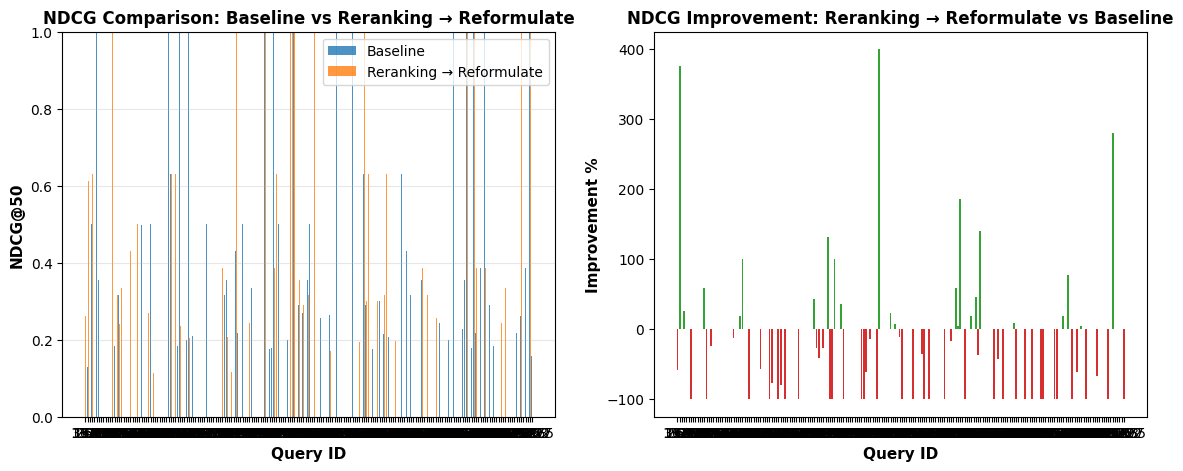

<Figure size 640x480 with 0 Axes>

In [10]:
# ============================================================================
# CELL 4: AGENT COMBINATIONS - Apply selected agent pipeline in order
# ============================================================================

agent_combo_results_dict = {}
agent_combo_ndcg_scores = {}
reformulated_queries_dict = {}

print("\n" + "="*80)
print(f"AGENT COMBINATION: {agent_combination_name.upper()}")
print("="*80)

# Process each query
for query_id in sample_queries:
    query_row = df_qrels[df_qrels['query_id'] == query_id].iloc[0]
    query_text = query_row['query_text']
    
    print(f"\nQuery {query_id}: {query_text}")
    
    # Start with baseline retrieval results
    baseline_doc_ids, baseline_scores, baseline_corpus = baseline_raw_results[query_id]
    
    # If no agents selected, skip processing
    if len(AGENT_SELECTION) == 0:
        final_doc_ids = baseline_doc_ids
        reformulated_query = None
    else:
        current_doc_ids = baseline_doc_ids
        current_scores = baseline_scores
        current_corpus = baseline_corpus
        current_query = query_text
        reformulated_query = None
        
        # Apply agents in the specified order
        for agent_idx, agent_vector in enumerate(AGENT_SELECTION):
            # Determine which agent to apply (one-hot encoding)
            agent_type = None
            for agent_pos, is_selected in enumerate(agent_vector):
                if is_selected:
                    agent_type = agent_pos
                    break
            
            if agent_type is None:
                continue  # No agent in this vector, skip
            
            elif agent_type == 1:  # Reranking
                print(f"  [Step {agent_idx + 1}] Applying Reranking Agent")
                current_doc_ids = apply_reranking_agent(current_query, current_doc_ids, current_scores, current_corpus, TOP_K)
            
            elif agent_type == 2:  # Reformulate
                print(f"  [Step {agent_idx + 1}] Applying Reformulation Agent")
                expanded_query = apply_reformulate_agent(current_query, current_doc_ids, current_scores, current_corpus, TOP_K)
                print(f"    Expanded query: {expanded_query}")
                reformulated_query = expanded_query
                # Retrieve with expanded query (use positional arg to avoid mismatched keyword)
                current_doc_ids, current_scores, current_corpus = retriever_func(expanded_query, TOP_K)
                current_query = expanded_query  # Update query for next agent
        
        final_doc_ids = current_doc_ids
    
    # Store the reformulated query for this query_id
    reformulated_queries_dict[query_id] = reformulated_query
    
    # Create graded relevance list by looking up actual relevance scores
    graded_relevance = [qrels_lookup.get((query_id, normalize_doc_id(doc_id)), 0) for doc_id in final_doc_ids]
    graded_relevance = deduplicate_graded_relevance(final_doc_ids, graded_relevance)
    
    agent_combo_results_dict[query_id] = graded_relevance
    print(f"  Graded relevance: {graded_relevance}")
    
    # Calculate NDCG
    ndcg = compute_ndcg(graded_relevance, query_id, k=TOP_K)
    agent_combo_ndcg_scores[query_id] = ndcg
    print(f"  NDCG@{TOP_K}: {ndcg:.4f}")

print("\n" + "="*80)
print(f"{agent_combination_name.upper()} RESULTS")
print("="*80)
for query_id, ndcg in agent_combo_ndcg_scores.items():
    print(f"Query {query_id}: NDCG@{TOP_K} = {ndcg:.4f}")

agent_combo_mean = np.mean(list(agent_combo_ndcg_scores.values()))
print(f"\nMean {agent_combination_name} NDCG@{TOP_K}: {agent_combo_mean:.4f}")

# ============================================================================
# CELL 5: COMPARATIVE RESULTS TABLE AND VISUALIZATION
# CELL 5: COMPARATIVE RESULTS TABLE AND VISUALIZATION

print("\n" + "="*80)
print(f"COMPARISON TABLE: BASELINE vs {agent_combination_name.upper()}")
print("="*80)

comparison_data = []
for query_id in sample_queries:
    baseline_ndcg = baseline_ndcg_scores[query_id]
    agent_ndcg = agent_combo_ndcg_scores[query_id]
    improvement = agent_ndcg - baseline_ndcg
    improvement_pct = (improvement / baseline_ndcg * 100) if baseline_ndcg > 0 else 0
    
    comparison_data.append({
        'Query ID': query_id,
        'Baseline NDCG': f"{baseline_ndcg:.4f}",
        f'{agent_combination_name} NDCG': f"{agent_ndcg:.4f}",
        'Δ NDCG': f"{improvement:+.4f}",
        'Δ %': f"{improvement_pct:+.2f}%"
    })

df_comparison = pd.DataFrame(comparison_data)
df_comparison = pd.DataFrame(comparison_data)
# Display all rows (no truncation)
with pd.option_context('display.max_rows', None):
    print("\n" + df_comparison.to_string(index=False))

print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
mean_improvement = agent_combo_mean - baseline_mean

print(f"Baseline Mean NDCG@{TOP_K}: {baseline_mean:.4f}")
print(f"{agent_combination_name} Mean NDCG@{TOP_K}: {agent_combo_mean:.4f}")
print(f"Mean Improvement: {mean_improvement:+.4f}")
print(f"Mean Improvement %: {(mean_improvement/baseline_mean*100):+.2f}%")

queries_improved = sum(1 for qid in sample_queries if agent_combo_ndcg_scores[qid] > baseline_ndcg_scores[qid])
print(f"Queries Improved: {queries_improved}/{len(sample_queries)}")
print("="*80)

# ===== QUERIES WITH BASELINE NDCG = 0 =====
print("\n" + "="*80)
print("QUERIES WITH BASELINE NDCG = 0")
print("="*80)

zero_baseline_data = []
for query_id in sample_queries:
    baseline_ndcg = baseline_ndcg_scores[query_id]
    if baseline_ndcg == 0:
        query_row = df_qrels[df_qrels['query_id'] == query_id].iloc[0]
        original_query = query_row['query_text']
        expanded_query = reformulated_queries_dict.get(query_id, "N/A")
        agent_ndcg = agent_combo_ndcg_scores[query_id]
        improvement_pct = (agent_ndcg / baseline_ndcg * 100) if baseline_ndcg > 0 else (agent_ndcg * 100 if agent_ndcg > 0 else 0)
        
        zero_baseline_data.append({
            'Query': original_query,
            'Expanded Query': expanded_query,
            'Improvement %': f"{improvement_pct:+.2f}%"
        })

if zero_baseline_data:
    df_zero_baseline = pd.DataFrame(zero_baseline_data)
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
        print("\n" + df_zero_baseline.to_string(index=False))
else:
    print("\nNo queries with baseline NDCG = 0 found.")

# ===== VISUALIZATION =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: NDCG Comparison Bar Chart
query_ids_str = [str(qid) for qid in sample_queries]
baseline_scores = [baseline_ndcg_scores[qid] for qid in sample_queries]
agent_scores = [agent_combo_ndcg_scores[qid] for qid in sample_queries]

x = np.arange(len(query_ids_str))
width = 0.35

axes[0].bar(x - width/2, baseline_scores, width, label='Baseline', alpha=0.8, color='#1f77b4')
axes[0].bar(x + width/2, agent_scores, width, label=agent_combination_name, alpha=0.8, color='#ff7f0e')
axes[0].set_xlabel('Query ID', fontsize=11, fontweight='bold')
axes[0].set_ylabel(f'NDCG@{TOP_K}', fontsize=11, fontweight='bold')
axes[0].set_title(f'NDCG Comparison: Baseline vs {agent_combination_name}', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(query_ids_str)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1.0])

# Plot 2: Improvement Percentage
improvements = []
colors = []
for qid in sample_queries:
    imp = ((agent_combo_ndcg_scores[qid] - baseline_ndcg_scores[qid]) / baseline_ndcg_scores[qid] * 100) if baseline_ndcg_scores[qid] > 0 else 0
    improvements.append(imp)
    colors.append('#2ca02c' if imp >= 0 else '#d62728')

axes[1].bar(query_ids_str, improvements, color=colors, alpha=0.8)
axes[1].bar(query_ids_str, improvements, color=colors, alpha=0.8)
axes[1].set_xlabel('Query ID', fontsize=11, fontweight='bold')
print("\n✓ Visualization complete")

axes[1].set_ylabel('Improvement %', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Improvement %', fontsize=11, fontweight='bold')
axes[1].set_title(f'NDCG Improvement: {agent_combination_name} vs Baseline', fontsize=12, fontweight='bold')
plt.show()

axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
plt.tight_layout()

axes[1].grid(axis='y', alpha=0.3)
axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(y=mean_improvement/baseline_mean*100, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_improvement/baseline_mean*100:+.2f}%')
axes[1].legend()
